<a href="https://colab.research.google.com/github/bismarxx/Machine-Learning-I-Actividad-7/blob/main/Ejercicio2_Clustering_Moons.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejercicio 2: Clustering sobre el dataset sintético *moons*
**K-Means, DBSCAN y Spectral Clustering + métricas de validación interna y externa**

**Plan de trabajo**
1. Generar y visualizar el dataset `make_moons`
2. K-Means (k = 2)
3. DBSCAN: elegir `eps` y `min_samples`
4. Spectral Clustering (k = 2)
5. Métricas de validación **interna** y **externa**
6. Comparación, visualización y conclusiones

> **Idea clave:** *moons* son dos "lunas" entrelazadas con **fronteras no lineales**. Como muestran las diapositivas, K-Means solo soporta fronteras lineales, mientras que DBSCAN y Spectral Clustering sí pueden separar formas no convexas. Este dataset sirve justamente para ver esa diferencia, y para comprobar que **las métricas internas pueden engañar**.

## 1. Generación de datos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, SpectralClustering
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    silhouette_score, calinski_harabasz_score, davies_bouldin_score,   # internas
    adjusted_rand_score, normalized_mutual_info_score, mutual_info_score,
    homogeneity_score, completeness_score, v_measure_score             # externas
)

RANDOM_STATE = 42

Forma de X: (500, 2) | Clases reales: [250 250]


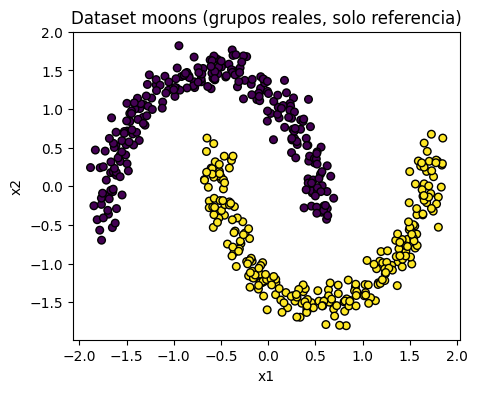

In [2]:
X, y_true = make_moons(n_samples=500, noise=0.07, random_state=RANDOM_STATE)
print("Forma de X:", X.shape, "| Clases reales:", np.bincount(y_true))

# Estandarización (buena práctica antes de clustering; ver diapositivas)
X_scaled = StandardScaler().fit_transform(X)

plt.figure(figsize=(5,4))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=y_true, cmap="viridis", edgecolor="k", s=30)
plt.title("Dataset moons (grupos reales, solo referencia)")
plt.xlabel("x1"); plt.ylabel("x2"); plt.show()

## 2. K-Means

Sabemos que hay 2 grupos, así que usamos **k = 2**. También revisamos el codo para ver si la inercia sugiere algo claro.

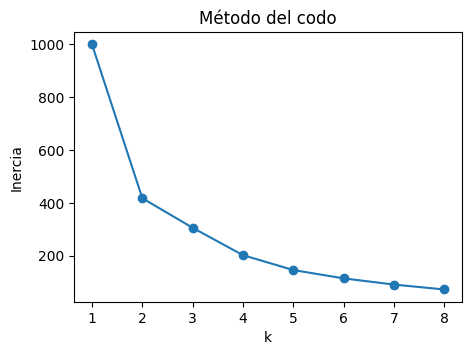

In [3]:
ks = range(1, 9)
inertias = [KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_scaled).inertia_ for k in ks]
plt.figure(figsize=(5,3.5))
plt.plot(list(ks), inertias, "o-"); plt.xlabel("k"); plt.ylabel("Inercia")
plt.title("Método del codo"); plt.show()

In [4]:
kmeans = KMeans(n_clusters=2, n_init=10, random_state=RANDOM_STATE)
labels_km = kmeans.fit_predict(X_scaled)
print("Tamaño de cada cluster:", np.bincount(labels_km))

Tamaño de cada cluster: [251 249]


> El codo no muestra una inflexión clara: los datos no son "bolas" compactas, que es lo que K-Means asume.

## 3. DBSCAN

Usamos el gráfico de distancias al k-ésimo vecino para orientar la elección de `eps` (se busca el codo).

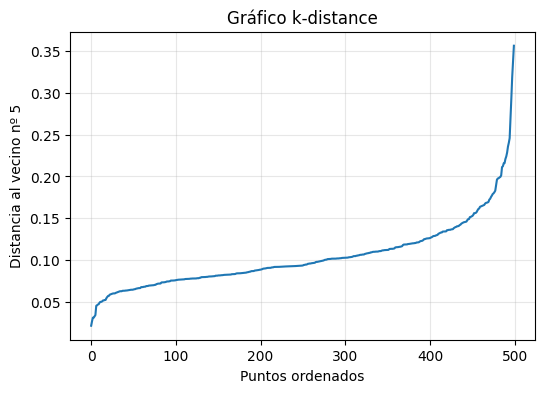

In [5]:
min_samples = 5
dist, _ = NearestNeighbors(n_neighbors=min_samples).fit(X_scaled).kneighbors(X_scaled)
kdist = np.sort(dist[:, -1])

plt.figure(figsize=(6,4))
plt.plot(kdist); plt.xlabel("Puntos ordenados")
plt.ylabel(f"Distancia al vecino nº {min_samples}")
plt.title("Gráfico k-distance"); plt.grid(alpha=.3); plt.show()

### Búsqueda de hiperparámetros (`eps`, `min_samples`)

In [6]:
def silhouette_sin_ruido(X, labels):
    mask = labels != -1
    return silhouette_score(X[mask], labels[mask]) if len(set(labels[mask])) > 1 else np.nan

rows = []
for eps in np.arange(0.1, 0.61, 0.05):
    for ms in [3, 5, 8, 10]:
        lab = DBSCAN(eps=eps, min_samples=ms).fit_predict(X_scaled)
        rows.append({"eps": round(eps, 2), "min_samples": ms,
                     "n_clusters": len(set(lab)) - (1 if -1 in lab else 0),
                     "ruido": int((lab == -1).sum()),
                     "silhouette": silhouette_sin_ruido(X_scaled, lab)})
grid = pd.DataFrame(rows)
grid.sort_values("silhouette", ascending=False).head(10)

,eps,min_samples,n_clusters,ruido,silhouette
3,0.10,10,2,470,0.956423
2,0.10,8,14,341,0.656486
1,0.10,5,24,118,0.478991
7,0.15,10,15,45,0.456106
11,0.20,10,2,8,0.394506
10,0.20,8,2,6,0.390782
15,0.25,10,2,2,0.389594
9,0.20,5,2,4,0.386864
13,0.25,5,2,0,0.385733
12,0.25,3,2,0,0.385733


La selección se hace **sin usar las etiquetas reales**: entre las configuraciones con al menos 2 clusters y como máximo 1 % de ruido, elegimos la de mayor silhouette.

In [7]:
cand = grid[(grid.n_clusters >= 2) & (grid.ruido <= 0.01 * len(X_scaled))]
best = cand.sort_values("silhouette", ascending=False).iloc[0]
print(best)

dbscan = DBSCAN(eps=float(best.eps), min_samples=int(best.min_samples))
labels_db = dbscan.fit_predict(X_scaled)
print("\nClusters encontrados:", len(set(labels_db)) - (1 if -1 in labels_db else 0))
print("Puntos de ruido (-1):", int((labels_db == -1).sum()))

eps             0.250000
min_samples    10.000000
n_clusters      2.000000
ruido           2.000000
silhouette      0.389594
Name: 15, dtype: float64

Clusters encontrados: 2
Puntos de ruido (-1): 2


## 4. Spectral Clustering

In [8]:
spectral = SpectralClustering(
    n_clusters=2,
    affinity="nearest_neighbors",   # grafo de vecinos: captura fronteras no lineales
    n_neighbors=15,
    assign_labels="kmeans",
    random_state=RANDOM_STATE
)
labels_sp = spectral.fit_predict(X_scaled)
print("Tamaño de cada cluster:", np.bincount(labels_sp))

Tamaño de cada cluster: [250 250]


## 5. Métricas de validación

**Interna** (solo datos + etiquetas de cluster): Silhouette (↑), Calinski-Harabasz (↑), Davies-Bouldin (↓).
**Externa** (compara con las clases reales): ARI (↑), NMI (↑), Información Mutua, Homogeneidad, Completitud y V-measure (↑).

En DBSCAN el ruido (`-1`) se excluye de las métricas internas.

In [9]:
def eval_interna(X, labels):
    mask = labels != -1
    if len(set(labels[mask])) < 2:
        return {"Silhouette": np.nan, "Calinski-Harabasz": np.nan, "Davies-Bouldin": np.nan}
    return {"Silhouette": silhouette_score(X[mask], labels[mask]),
            "Calinski-Harabasz": calinski_harabasz_score(X[mask], labels[mask]),
            "Davies-Bouldin": davies_bouldin_score(X[mask], labels[mask])}

def eval_externa(y, labels):
    return {"ARI": adjusted_rand_score(y, labels),
            "NMI": normalized_mutual_info_score(y, labels),
            "Mutual Info": mutual_info_score(y, labels),
            "Homogeneidad": homogeneity_score(y, labels),
            "Completitud": completeness_score(y, labels),
            "V-measure": v_measure_score(y, labels)}

resultados = {"K-Means": labels_km, "DBSCAN": labels_db, "Spectral": labels_sp}
interna = pd.DataFrame({n: eval_interna(X_scaled, l) for n, l in resultados.items()}).T
externa = pd.DataFrame({n: eval_externa(y_true, l) for n, l in resultados.items()}).T

print("=== VALIDACIÓN INTERNA ===");  display(interna.round(3))
print("\n=== VALIDACIÓN EXTERNA (vs. grupos reales) ==="); display(externa.round(3))

=== VALIDACIÓN INTERNA ===


,Silhouette,Calinski-Harabasz,Davies-Bouldin
K-Means,0.494,693.848,0.812
DBSCAN,0.390,440.393,1.012
Spectral,0.386,433.882,1.022



=== VALIDACIÓN EXTERNA (vs. grupos reales) ===


,ARI,NMI,Mutual Info,Homogeneidad,Completitud,V-measure
K-Means,0.445,0.352,0.244,0.352,0.352,0.352
DBSCAN,0.992,0.980,0.690,0.996,0.964,0.980
Spectral,1.000,1.000,0.693,1.000,1.000,1.000


In [10]:
# Referencia: métricas internas de la partición REAL (las dos lunas)
print("Métricas internas de la partición real:")
display(pd.Series(eval_interna(X_scaled, y_true)).round(3).to_frame("Partición real").T)

Métricas internas de la partición real:


,Silhouette,Calinski-Harabasz,Davies-Bouldin
Partición real,0.386,433.882,1.022


### Tablas cruzadas: clusters vs. grupos reales

In [11]:
for nombre, lab in resultados.items():
    print(f"--- {nombre} ---")
    display(pd.crosstab(pd.Series(lab, name="cluster"), pd.Series(y_true, name="luna real")))

--- K-Means ---


luna real,0,1
cluster,,
0,209,42
1,41,208


--- DBSCAN ---


luna real,0,1
cluster,,
-1,1,1
0,0,249
1,249,0


--- Spectral ---


luna real,0,1
cluster,,
0,0,250
1,250,0


## 6. Visualización

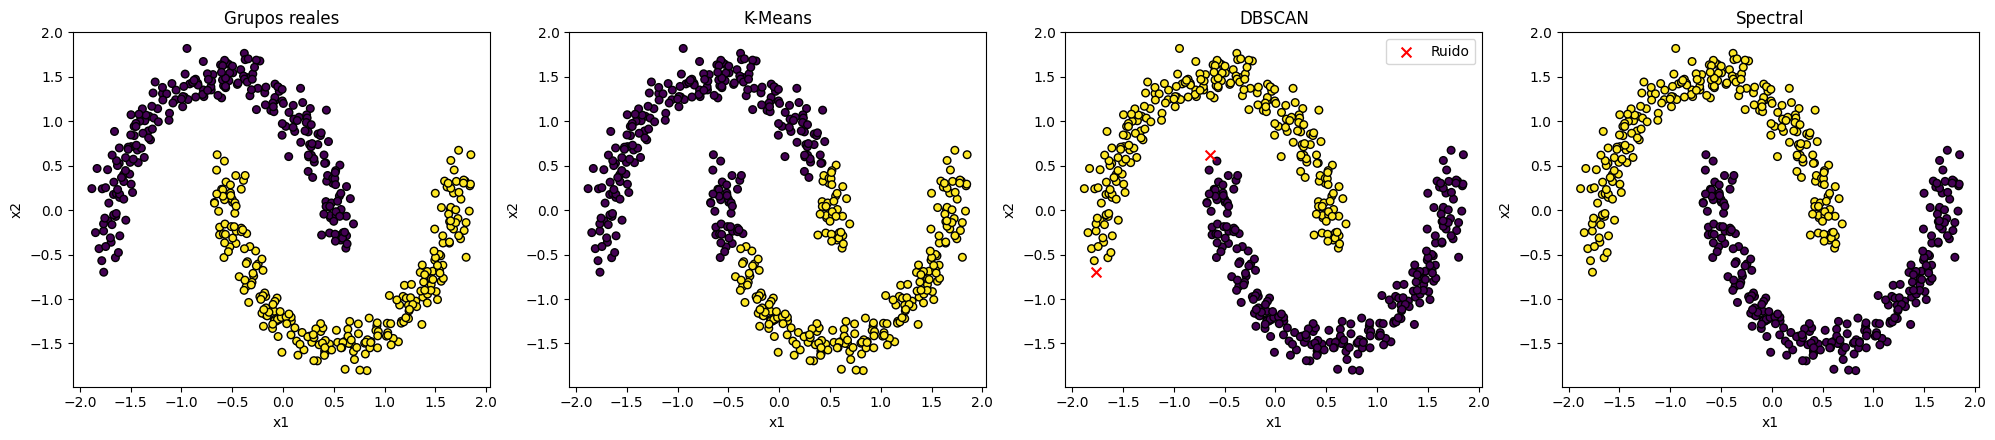

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
axes[0].scatter(X_scaled[:,0], X_scaled[:,1], c=y_true, cmap="viridis", edgecolor="k", s=30)
axes[0].set_title("Grupos reales")

for ax, (nombre, lab) in zip(axes[1:], resultados.items()):
    ruido = lab == -1
    ax.scatter(X_scaled[~ruido,0], X_scaled[~ruido,1], c=lab[~ruido], cmap="viridis", edgecolor="k", s=30)
    if ruido.any():
        ax.scatter(X_scaled[ruido,0], X_scaled[ruido,1], c="red", marker="x", s=50, label="Ruido")
        ax.legend()
    ax.set_title(nombre)
for ax in axes:
    ax.set_xlabel("x1"); ax.set_ylabel("x2")
plt.tight_layout(); plt.show()

## 7. Resumen y conclusiones

In [13]:
resumen = pd.concat([interna, externa], axis=1).round(3)
resumen["Nº clusters"] = [len(set(l)) - (1 if -1 in l else 0) for l in resultados.values()]
resumen["Ruido"] = [int((l == -1).sum()) for l in resultados.values()]
resumen

,Silhouette,Calinski-Harabasz,Davies-Bouldin,ARI,NMI,Mutual Info,Homogeneidad,Completitud,V-measure,Nº clusters,Ruido
K-Means,0.494,693.848,0.812,0.445,0.352,0.244,0.352,0.352,0.352,2,0
DBSCAN,0.390,440.393,1.012,0.992,0.980,0.690,0.996,0.964,0.980,2,2
Spectral,0.386,433.882,1.022,1.000,1.000,0.693,1.000,1.000,1.000,2,0


### Interpretación

- **K-Means** corta el espacio con una frontera lineal, así que **parte cada luna por la mitad**. Su ARI y NMI son bajos (ARI ≈ 0.45).
- **DBSCAN** y **Spectral Clustering** recuperan las dos lunas casi a la perfección (ARI ≈ 1), porque agrupan por **conectividad/densidad** y no por distancia a un centroide. DBSCAN además no necesitó que le dijéramos el número de grupos.
- **Las métricas internas engañan aquí:** K-Means obtiene un Silhouette y un Calinski-Harabasz **mayores** que la partición correcta, porque esas métricas premian grupos compactos y redondeados. Las lunas correctas son alargadas y se "abrazan", así que puntúan peor internamente.
- **Lección:** usar solo validación interna puede llevar a elegir el algoritmo equivocado cuando los clusters no son convexos. Cuando hay etiquetas de referencia (o conocimiento del dominio), conviene complementar con validación externa y con la inspección visual.
- **Costo:** Spectral Clustering es más lento que K-Means y DBSCAN, aunque con 500 puntos apenas se nota.

> Los valores exactos pueden variar con `noise` y la semilla aleatoria; la comparación relativa se mantiene.